In [1]:
import os
import sys
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
from pathlib import Path
# Project root = MTinv_OT (parent of this experiment folder)

_project_root = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "src" / "mt2d_inv").is_dir():
        _project_root = str(_p)
        break
if _project_root is None:
    raise RuntimeError("Could not find MTinv_OT project root (src/mt2d_inv)")
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.mt2d_inv import MT2DInverterWeightedCost
from src.mt2d_inv.io import ExperimentLogger
from pathlib import Path

logger = ExperimentLogger(
    model_tag="Cascadia",
    output_root=Path("test_results"),
)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


In [2]:
PLOT_CONFIG = {
    "cmap": "jet_r",
    "clip_to_stations": True,
    "ylim": [200, 0],
    "profile_extend_km": 20,
    "vmin": 0,
    "vmax": 4,
    "mc_cmap": "jet_r",
    "mc_clip_to_stations": True,
    "mc_ylim": [200, 0],
    "mc_profile_extend_km": 20,
    "mc_vmin": 0,
    "mc_vmax": 4,
    "im_cmap": "jet_r",
    "im_clip_to_stations": True,
    "im_ylim": [200, 0],
    "im_profile_axis_width_km": 500,
    "df_station_indices": "all",
    "df_plot_noise_cap": None,
    "pf_depth_limit_km": 50,
}

save_plot_kwargs = PLOT_CONFIG


In [3]:
from __future__ import annotations

import torch
from src.mt2d_inv.data_prep import PrepareData

EDI_DIR = "Cascadia-CAFE-profile-3"
FREQ_MIN_HZ = 1e-5
FREQ_MAX_HZ = 1e-1
MAG_DECLINATION_DEG = 15.0
STRIKE_TRUE_DEG = 0.0
STRIKE_MAGNETIC_DEG = float(STRIKE_TRUE_DEG - MAG_DECLINATION_DEG)

prep = PrepareData(
    edi_dir=EDI_DIR,
    mag_declination_deg=MAG_DECLINATION_DEG,
    edi_impedance_unit="mv/km/nt",
    freq_min_hz=FREQ_MIN_HZ,
    freq_max_hz=FREQ_MAX_HZ,
    clean_data=False,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

freqs_t, stations_t, data_dict = prep.run_all_simple(
    rotate=True,
    strike_true_deg=STRIKE_TRUE_DEG,
    strike_magnetic_deg=STRIKE_MAGNETIC_DEG,
    device=device,
)
print(f"[pipeline] Fixed strike (true N) = {STRIKE_TRUE_DEG}°, rotation (mag) = {STRIKE_MAGNETIC_DEG:.2f}°")
print(f"[pipeline] Stations: {len(prep.mt_objects)} (all EDI kept; cleaning only masks bad points)")


Using EDI_DIR = Cascadia-CAFE-profile-3
Found 24 EDI files
[PrepareData] Converted impedance units to ohms for 24/24 stations (edi_impedance_unit='mv/km/nt').
[PrepareData] Loaded Tipper for 15/24 stations (90° strike check enabled).
[PrepareData] Skipped frequency harmonization. Stations retain their original frequencies.
Estimated regional strike (magnetic reference) = -16.26274842248452
Magnetic declination (manual, east positive) = 15.000 deg
Estimated regional strike (true north reference) = -1.2627484224845205
All stations rotated by -15.00 degrees
[PrepareData] Exported Tensor shape: Frequencies=20, Stations=24
[pipeline] Fixed strike (true N) = 0.0°, rotation (mag) = -15.00°
[pipeline] Stations: 24 (all EDI kept; cleaning only masks bad points)


In [4]:
nza = 10
z_air = -np.logspace(np.log10(10), np.log10(50000), nza)
z_air = np.flip(z_air)
z_air = np.append(z_air, 0)

nz = 80
z_sub = np.logspace(np.log10(10), np.log10(300000), nz)
zn = np.concatenate([z_air[:-1], np.array([0]), z_sub])

y_center = np.linspace(-250000, 250000, 201)
y_left = -np.logspace(np.log10(255000), np.log10(950000), 20)
y_right = np.logspace(np.log10(255000), np.log10(950000), 20)
y_left = np.flip(y_left)
yn = np.concatenate([y_left, y_center, y_right])

print("新的网格统计:")
print(f" - 垂向第一层厚度: {zn[nza+1] - zn[nza]:.1f} m")
print(f" - 最大深度: {zn[-1]/1000:.1f} km")
print(f" - 中心区横向分辨率: {y_center[1] - y_center[0]:.1f} m")
print(f" - 网格总数: {len(zn)-1} x {len(yn)-1}")


新的网格统计:
 - 垂向第一层厚度: 10.0 m
 - 最大深度: 300.0 km
 - 中心区横向分辨率: 2500.0 m
 - 网格总数: 90 x 240


In [5]:
inv = MT2DInverterWeightedCost(
    yn=torch.as_tensor(yn, dtype=torch.float64, device=device),
    zn=torch.as_tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs_t,
    stations=stations_t,
    device=device,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=50,
)
inv.load_obs_data(data_dict, noise_floor=0.15)
w_d_point = inv.update_ot_w_d_per_point_from_noise(
    w_d_scale=[1.5, 1, 1, 1],
    normalize="mean",
)


✓ Random seed set: 42
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.2665
   phi(normalized) noise mean: 0.2643
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.2632
   phi(normalized) noise mean: 0.2619
✓ 2D data error propagation completed
Computing data weights (Target Noise: 15.0%)
  - Resistivity Error Floor: 15.0%
  - Phase Error Floor:       4.290 deg
✓ MSE data weights normalized (mean): scale=5.894912e+00
✓ Observed data loaded from file
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=tensor(356, 4)@cuda, blur=0.0100, scale=0.9, reach=None


✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


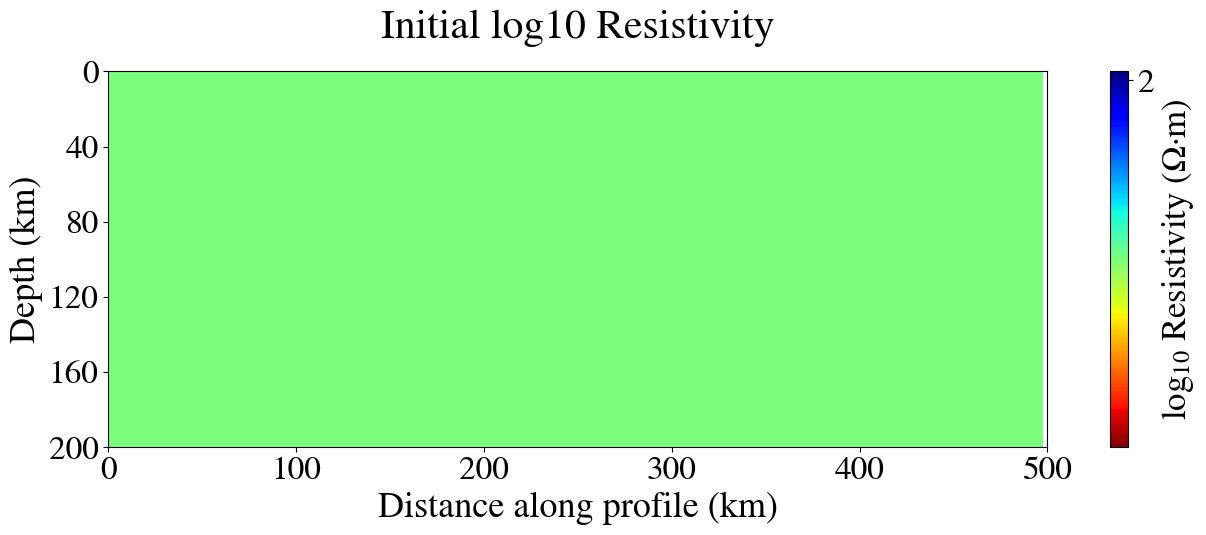

✓ Optimizer: AdamW, lr=0.8, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.8, weight_decay=0.0
Epoch 1/200 [   0.5%]
  Elapsed: 0:00:05 | Remaining: ~0:16:10 | ETA: 17:06:57
  Epoch time: 4.88s | Avg: 4.88s
  Total: 1.5137e+02 | Data(mse): 1.5137e+02
  [Cost weights] w_s=1.000, w_f=1.000, w_d=tensor([[1.5000, 1.0089, 1.0000, 1.0000],
        [1.5000, 1.0089, 1.0000, 1.0000],
        [1.5000, 1.0089, 1.0000, 1.0000],
        ...,
        [1.5000, 1.0089, 1.0000, 1.0000],
        [1.5000, 1.0089, 1.0000, 1.0000],
        [1.5000, 1.0089, 1.0000, 1.0000]], device='cuda:0')
  Misfit(RMS χ²): 10.257 | Rough: 0.00e+00 | Lam: 0.1000000
  OT-distance(6D, view-only): 1.031954e+02
  GradNorms: |g_d|=9.650e-02 | |λ·g_m|=1.000e-13
 [Auto-Lambda] Epoch 10: Adjusted 1.00e-01 -> 2.85e-03 (ratio=1.170e-02)
Epoch 11/200 [   5.5%]
  Elapsed: 0:00:51 | Remaining: ~0:14:30 | ETA: 17:06:02
  Epoch time: 4.58s | Avg: 4.60s
  Total: 7.7498e+01 | Data(mse): 5.1422e+01
  Misfit(RMS χ²): 5.978 | Rough: 9.15e+03 | La

In [6]:
inv.set_forward_operator()
inv.initialize_model(initial_sigma=0.03)

inv.plot_initial_model(
    clip_to_stations=PLOT_CONFIG["im_clip_to_stations"],
    ylim=PLOT_CONFIG["im_ylim"],
    profile_axis_width_km=PLOT_CONFIG["im_profile_axis_width_km"],
)

final_sigma = inv.run_inversion(
    n_epochs=200,
    mode="mse",
    progress_interval=10,
    current_lambda=0.1,
    use_adaptive_lambda=True,
    lr=0.8,
    update_interval=10,
    norm_type="L2",
    alpha=0.8,
    rms_chi2_stop=1.05,
    use_depth_weights=True,
    use_ot_weights=True,
    enable_blur_anneal=True,
    warmup_epochs=0,
)

print("done; sigma range:", final_sigma.min().item(), final_sigma.max().item())


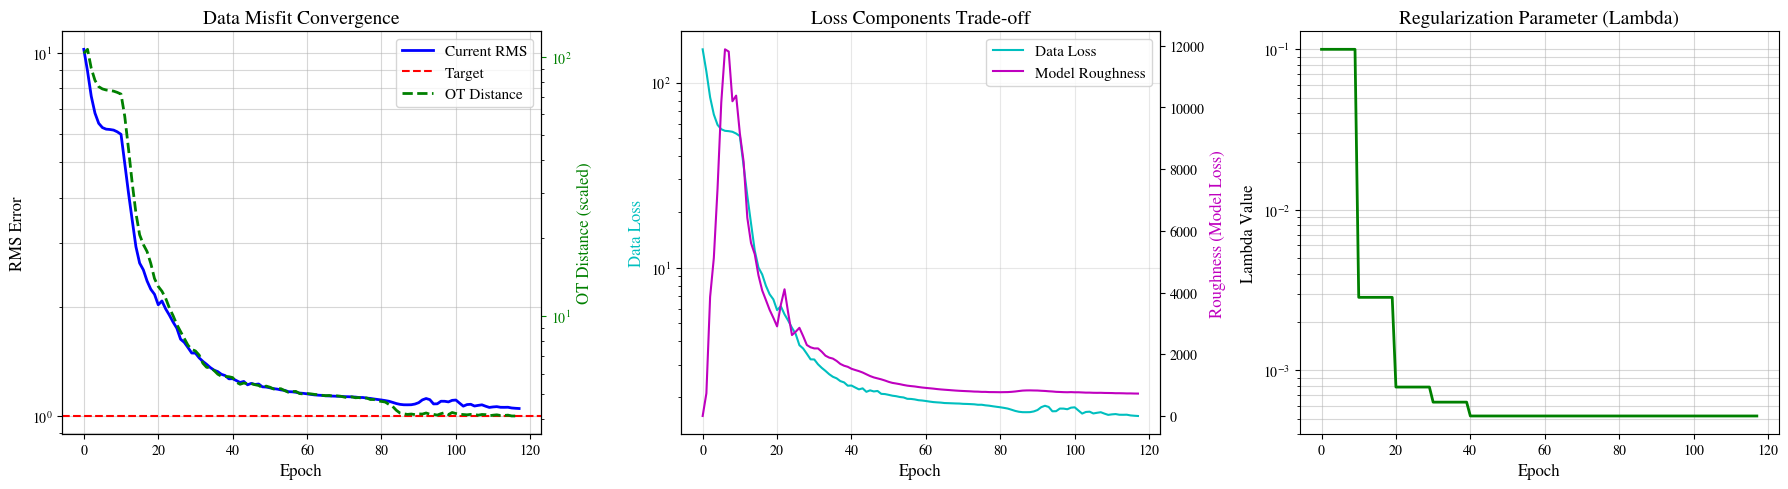

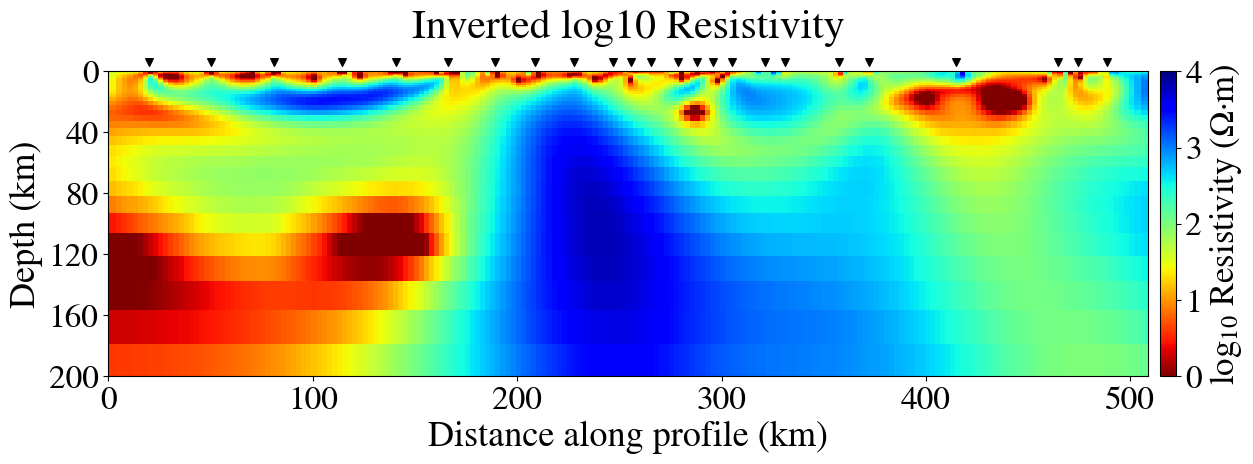

6.81292e-05 0.1


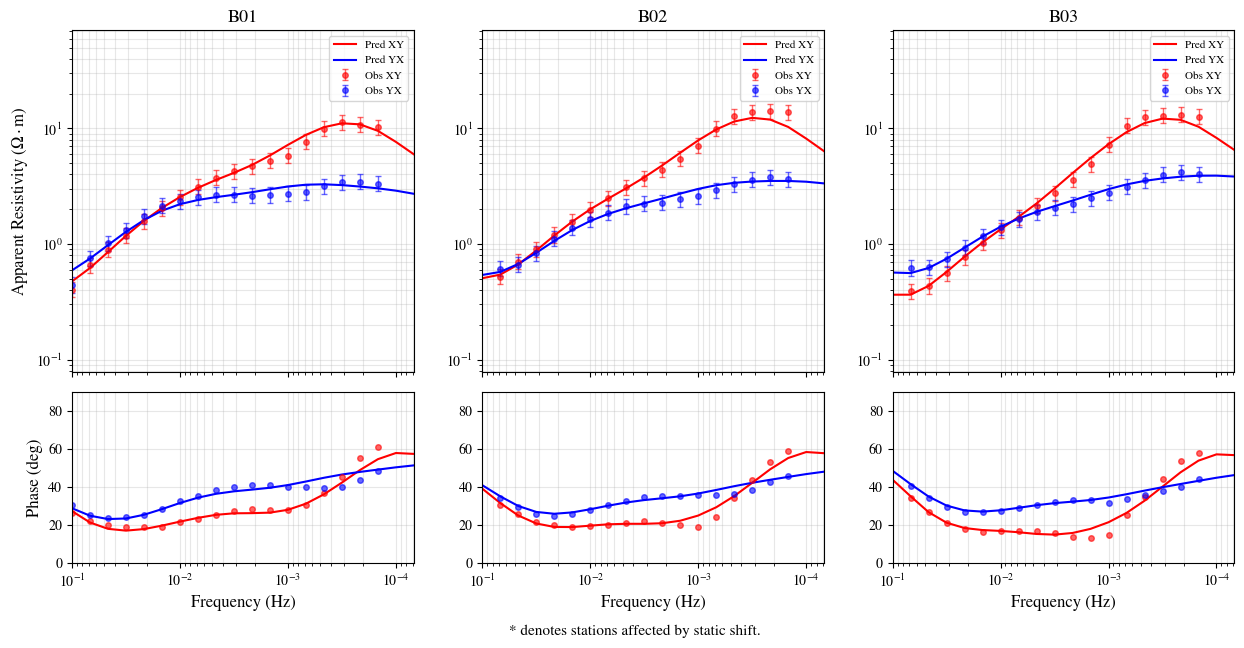

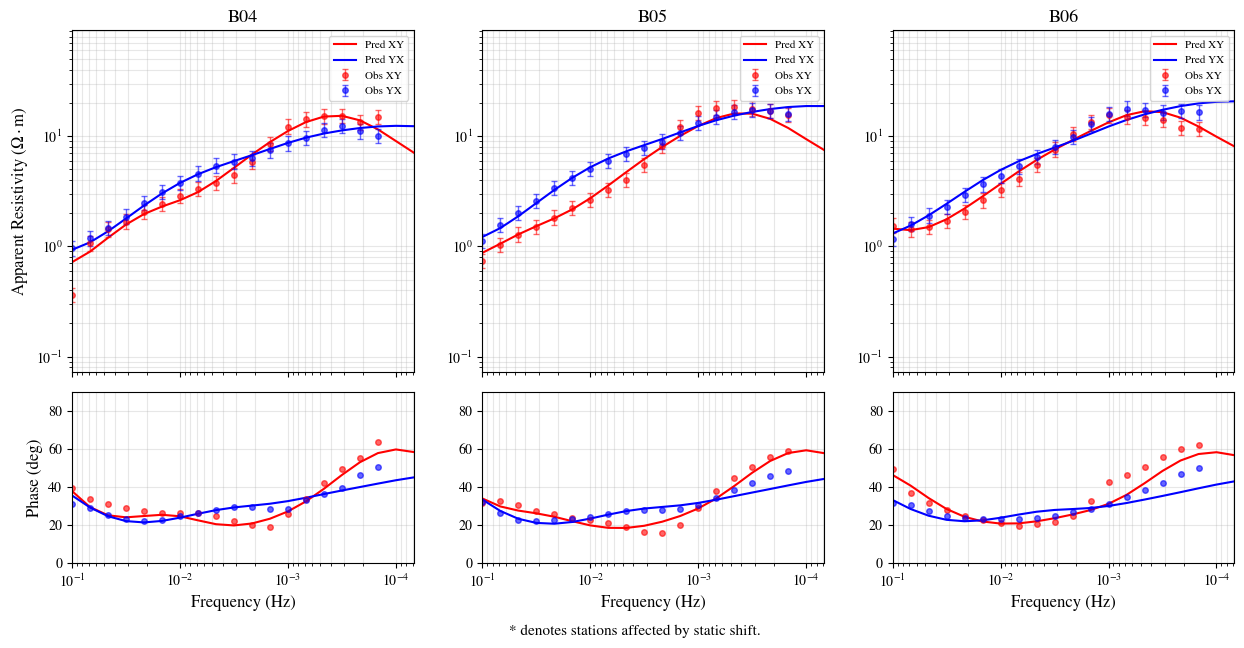

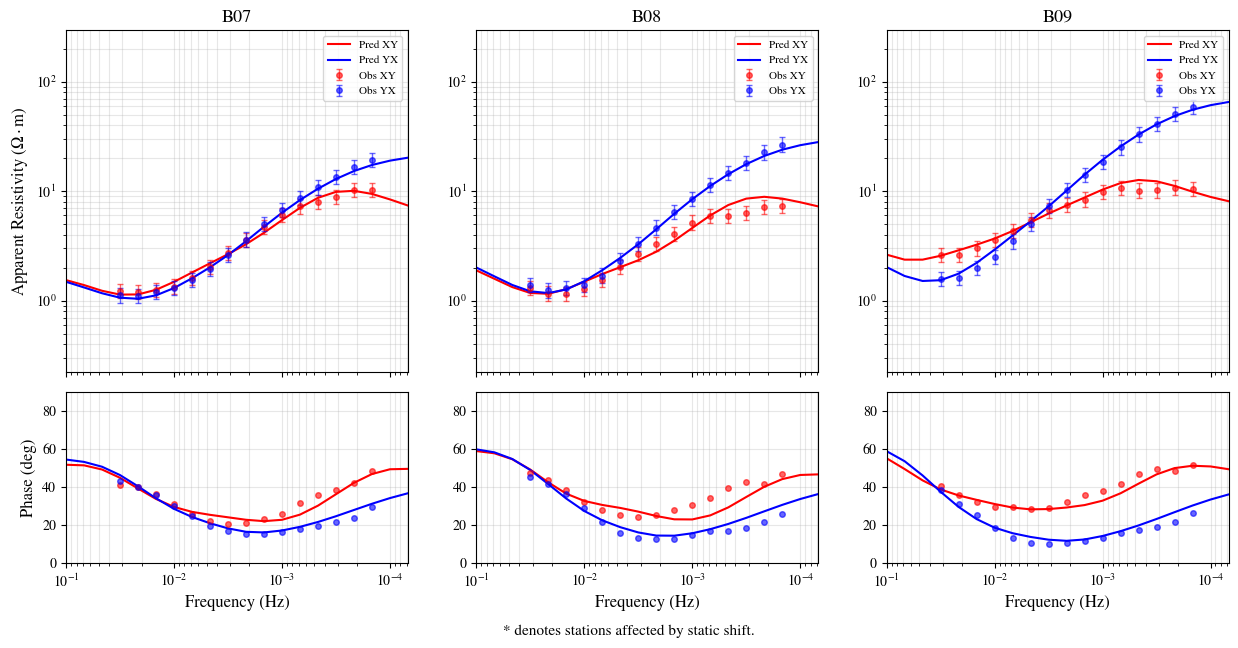

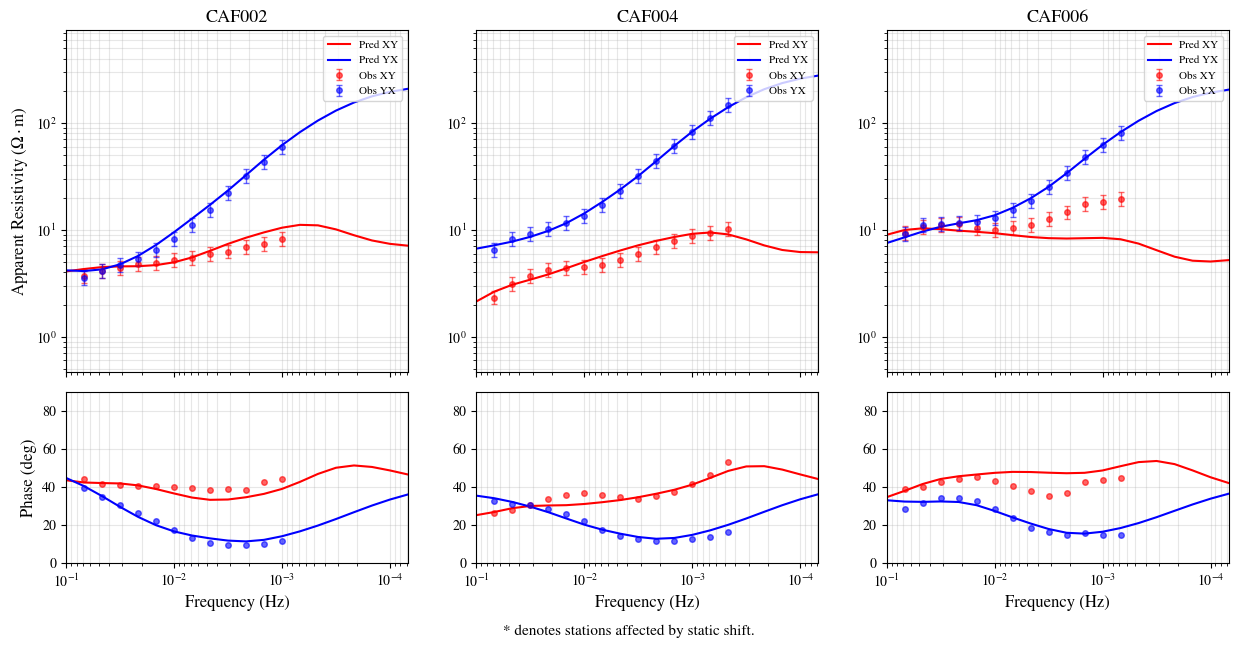

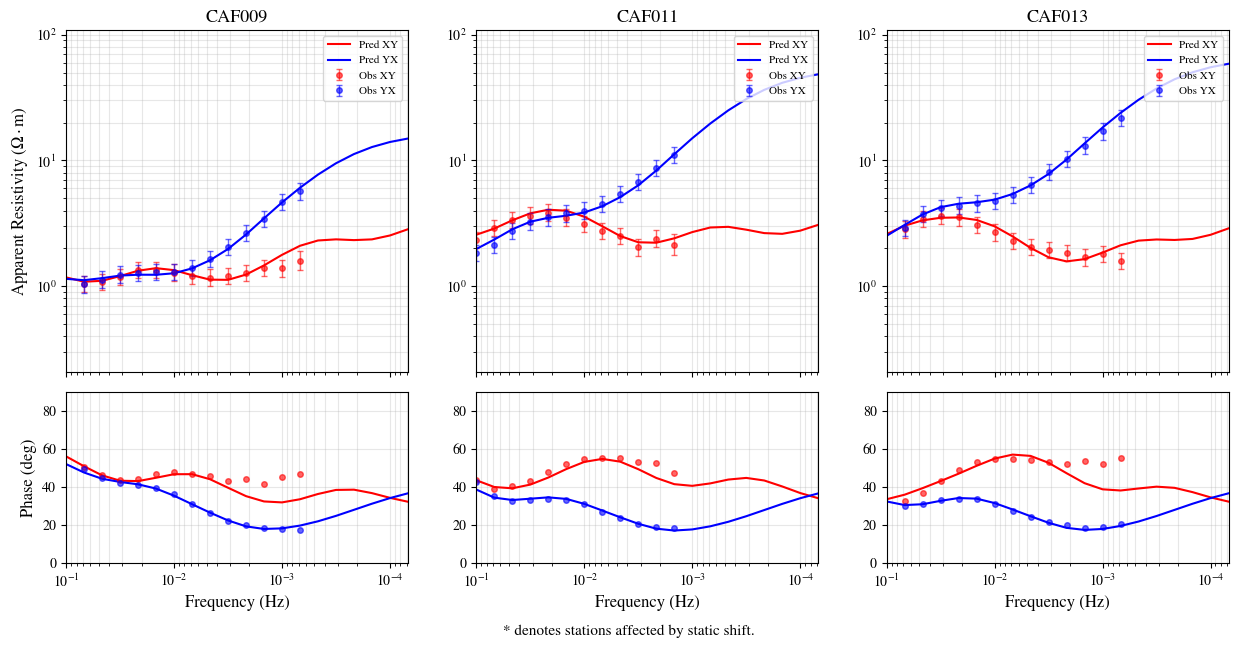

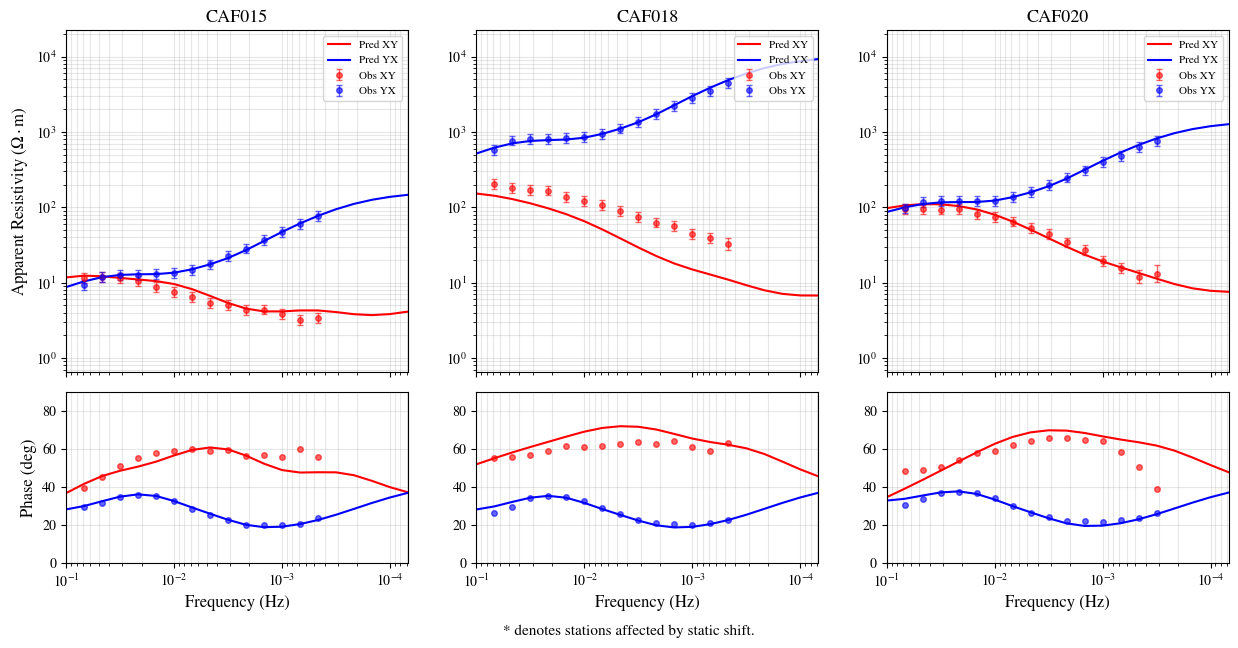

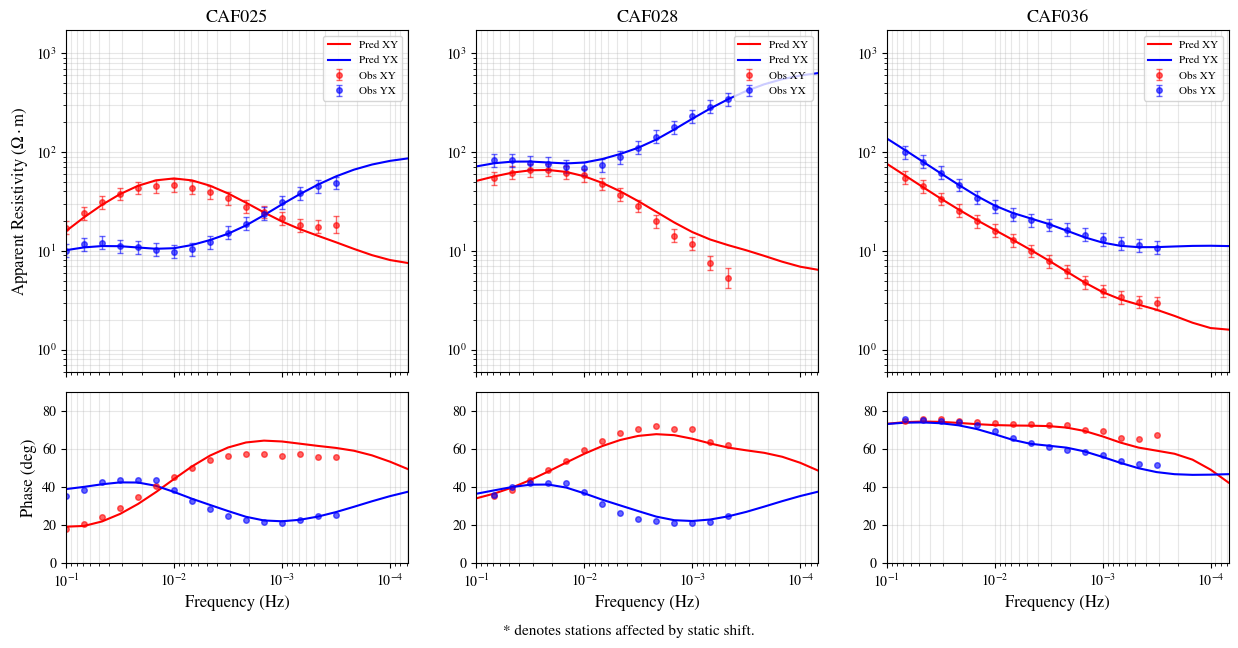

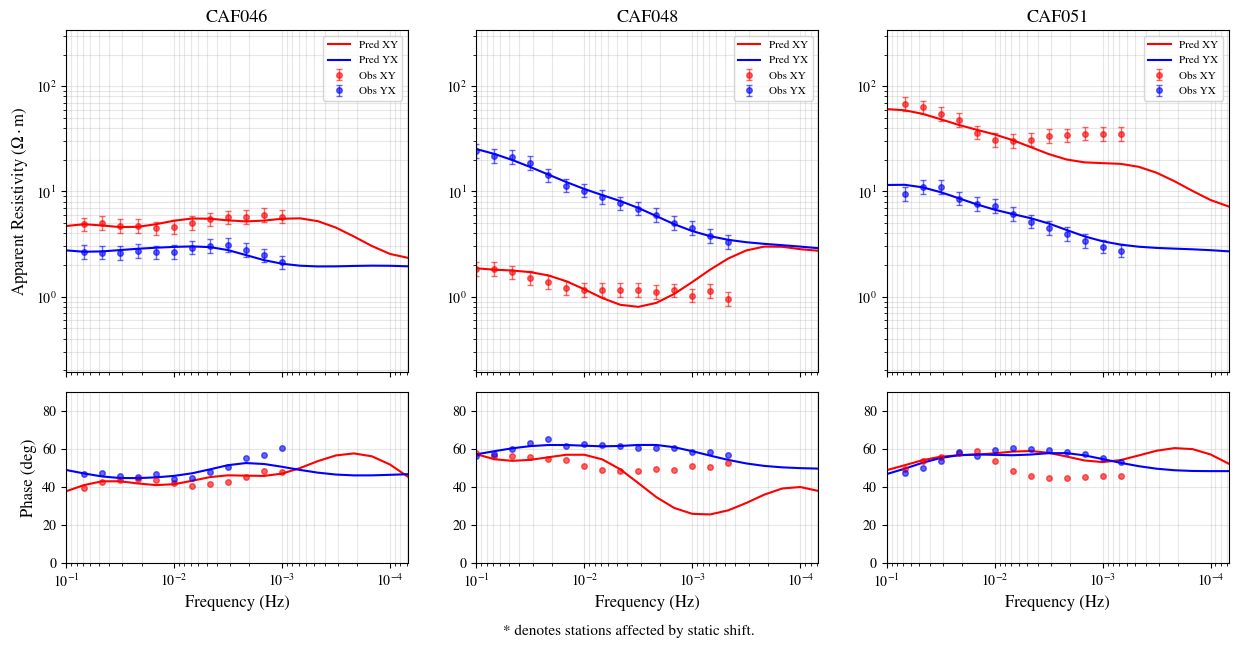

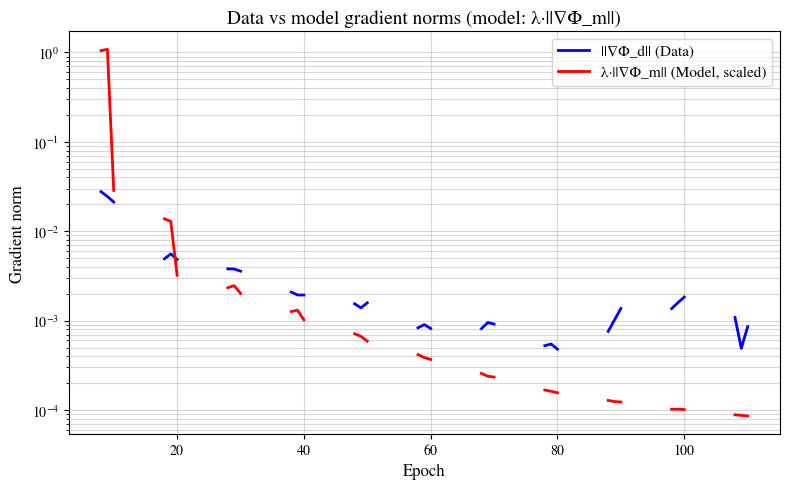

In [7]:
inv.plot_loss_history()

inv.plot_model_comparison(
    cmap=PLOT_CONFIG["mc_cmap"],
    clip_to_stations=PLOT_CONFIG["mc_clip_to_stations"],
    ylim=PLOT_CONFIG["mc_ylim"],
    profile_extend_km=PLOT_CONFIG["mc_profile_extend_km"],
    vmin=PLOT_CONFIG["mc_vmin"],
    vmax=PLOT_CONFIG["mc_vmax"],
)

print(freqs_t.min().item(), freqs_t.max().item())
batch_size = 3
n_stations = len(inv.stations)
for start in range(0, n_stations, batch_size):
    end = min(start + batch_size, n_stations)
    station_indices = list(range(start, end))
    inv.plot_data_fitting(station_indices=station_indices)
inv.plot_gradient_history()


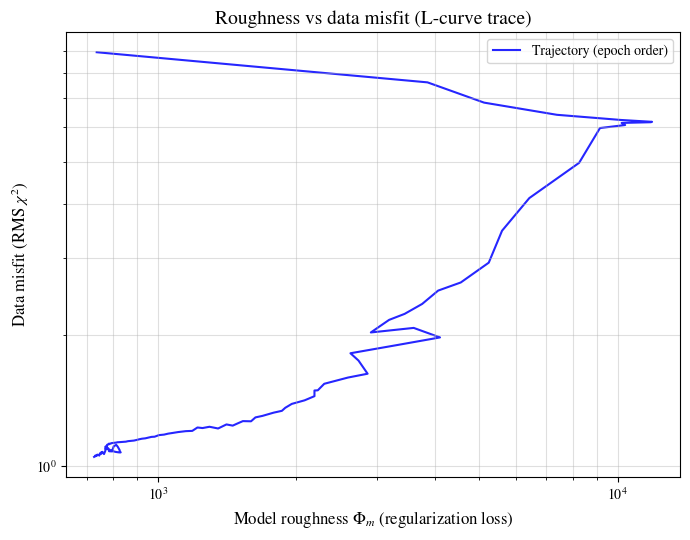

In [8]:
inv.plot_roughness_misfit_curve()


In [9]:
logger.save_from_inverter(
    inv,
    run_name="mse_epoch200",
    plot_kwargs=save_plot_kwargs,
)



Saving results to: test_results/Cascadia/2026-08-11_17-00-03_mse_epoch200
计算恢复率时报错了: sig_true not set in inverter. Please set inv.sig_true first.
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
  Note: ignored unsupported kwargs for plot_model_comparison: df_plot_noise_cap, df_station_indices, im_clip_to_stations, im_cmap, im_profile_axis_width_km, im_ylim, mc_clip_to_stations, mc_cmap, mc_profile_extend_km, mc_vmax, mc_vmin, mc_ylim, pf_depth_limit_km
  ✓ model_comparison.png/.pdf
  Note: ignored unsupported kwargs for plot_initial_model: df_plot_noise_cap, df_station_indices, im_clip_to_stations, im_cmap, im_profile_axis_width_km, im_ylim, mc_clip_to_stations, mc_cmap, mc_profile_extend_km, mc_vmax, mc_vmin, mc_ylim, pf_depth_limit_km
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 8 plots saved to test_results/Cascadia/2026-08-11_17-00-03_mse_epoch200/figures/data_fitting (24 stations)

PosixPath('test_results/Cascadia/2026-08-11_17-00-03_mse_epoch200')